# aiudio — A Tour of the Pipeline (from Python)

**aiudio** is an AI-native digital audio processing framework. Its real-time core is
C++ (the audio thread must never allocate, lock, or block); a thin **Python layer**
(nanobind) lets you *build, run, and edit* audio graphs and exchange audio as numpy
arrays — without touching the real-time thread (ADR-0002).

This notebook is a guided tour of everything the Python bindings expose today, with
explanations of *why* the pipeline is shaped the way it is — and a clear list at the
end of the features that exist in the C++ core but are **not (yet) controllable from
Python**.

**What we'll cover**
1. The audio data format
2. Building a graph (nodes + edges, the node contract, validation)
3. The executor — compile, then run on numpy
4. Real DSP — a biquad low-pass (with a spectrum plot)
5. Mixing — fan-out & fan-in
6. Metering (dBFS)
7. Live edits — params and atomic graph swaps (the agent's hook)
8. Offline file rendering
9. **What you can't control from Python (yet)** — and why


## 0. Setup

Install the package first (`pip install .` from the repo root), then import it. The
graph engine and all DSP are C++; here we only see the Python handles.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import aiudio

print("aiudio", aiudio.__version__)
print("exposed:", [n for n in dir(aiudio) if not n.startswith("_")])
SR = 48000.0  # the pipeline's working sample rate

aiudio 0.0.1
exposed: ['Graph', 'GraphExecutor', 'OfflineBackend', 'WavFormat']


## 1. The audio data format

Inside the pipeline audio is **planar 32-bit float, nominal full-scale ±1.0**, processed
in **blocks**. In numpy that's an array of shape **`(channels, frames)`** — one row per
channel. (Devices/files use interleaved and/or int16; the C++ edges convert at the
boundary. See `docs/73-digital-audio-encoding.md`.)

In [2]:
block = np.ones((1, 8), dtype=np.float32)   # 1 channel, 8 frames, full-scale
print("shape (channels, frames):", block.shape, "dtype:", block.dtype)

shape (channels, frames): (1, 8) dtype: float32


## 2. Build a graph — the typed IR

A graph is **nodes** (processors) connected by **edges** (output port → input port).
Every node obeys one contract (`process(in, out, frames, time)` + ports + params). From
Python you create nodes with factory methods that return a **node id** (an int), then
`connect` them.

`validate()` enforces the rules: ports in range, **each input port driven by at most one
edge** (mix with a `SumNode`, not two edges into one port), and **no cycles** (it's a DAG).

In [3]:
g = aiudio.Graph()
src  = g.add_source()      # 0 in, 1 out — the graph's entry (fed by the executor)
gain = g.add_gain(0.5)     # 1 in, 1 out — multiply by 0.5
sink = g.add_sink()        # 1 in, 0 out — the graph's exit (read by the executor)
g.connect(src, 0, gain, 0)
g.connect(gain, 0, sink, 0)

ok, err = g.validate()
print(f"nodes={g.node_count}  validate={ok}  {err!r}")

nodes=3  validate=True  ''


`validate()` is also how bad graphs are caught. Here's a **cycle** being rejected:

In [4]:
bad = aiudio.Graph()
a, b = bad.add_gain(1.0), bad.add_gain(1.0)
bad.connect(a, 0, b, 0)
bad.connect(b, 0, a, 0)        # a -> b -> a
print("cyclic graph validate():", bad.validate())

cyclic graph validate(): (False, 'graph contains a cycle')


## 3. The executor — compile, then run on numpy

The **`GraphExecutor`** compiles a graph into a static, topologically-ordered schedule
with pre-allocated buffers, then runs it block by block. Crucially, the executor *is* the
real-time callback the C++ backends drive — so the **same** compiled graph runs live on a
device (in C++) and here on numpy.

`process()` is the numpy bridge: `(channels, frames)` float32 in → out.

In [5]:
ex = aiudio.GraphExecutor()
ex.compile(g, channels=1, sample_rate=SR, max_block=1024)
print("compiled:", ex.compiled)

x = np.ones((1, 256), dtype=np.float32)
y = ex.process(x)
print("in[0]=", x[0, 0], " -> out[0]=", y[0, 0], " (gain 0.5)")
assert np.allclose(y, 0.5)

compiled: True
in[0]= 1.0  -> out[0]= 0.5  (gain 0.5)


## 4. Real DSP — a biquad low-pass

`add_biquad_lowpass(freq, q, sample_rate)` is a genuine stateful filter (RBJ cookbook).
Let's pass a **300 Hz + 5 kHz** mix through a 1 kHz low-pass and look at the spectrum: the
5 kHz tone should be strongly attenuated.

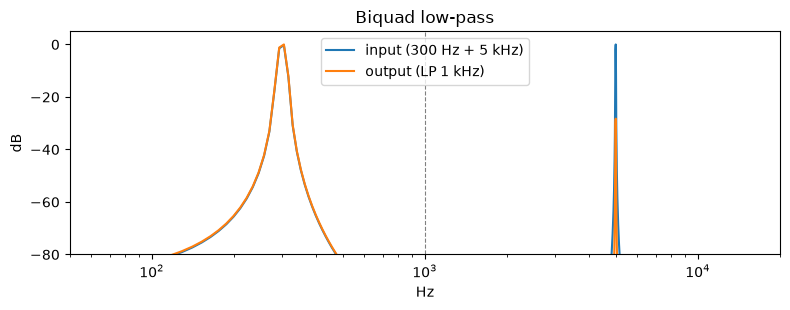

In [6]:
g_lp = aiudio.Graph()
s  = g_lp.add_source()
lp = g_lp.add_biquad_lowpass(1000.0, 0.707, SR)
k  = g_lp.add_sink()
g_lp.connect(s, 0, lp, 0); g_lp.connect(lp, 0, k, 0)

ex_lp = aiudio.GraphExecutor()
ex_lp.compile(g_lp, channels=1, sample_rate=SR, max_block=4096)

n = 4096
t = np.arange(n) / SR
sig = (0.4*np.sin(2*np.pi*300*t) + 0.4*np.sin(2*np.pi*5000*t)).astype(np.float32).reshape(1, n)
out = ex_lp.process(sig)

def spectrum_db(x):
    X = np.abs(np.fft.rfft(x[0] * np.hanning(len(x[0]))))
    return 20*np.log10(X / (X.max() + 1e-12) + 1e-9)

freqs = np.fft.rfftfreq(n, 1/SR)
plt.figure(figsize=(8, 3.2))
plt.semilogx(freqs, spectrum_db(sig), label="input (300 Hz + 5 kHz)")
plt.semilogx(freqs, spectrum_db(out), label="output (LP 1 kHz)")
plt.axvline(1000, ls="--", c="gray", lw=0.8); plt.xlim(50, 20000); plt.ylim(-80, 5)
plt.xlabel("Hz"); plt.ylabel("dB"); plt.legend(); plt.title("Biquad low-pass"); plt.tight_layout(); plt.show()

## 5. Mixing — fan-out and fan-in

One output port can feed **many** edges (**fan-out**). To *combine* signals you use a
multi-input node (**fan-in**) — a `SumNode` — never two edges into one input port.

Here the source fans out to two gains (0.5 and 0.3) which a `SumNode` mixes: 1.0 → 0.8.

In [7]:
g_mix = aiudio.Graph()
s  = g_mix.add_source()
ga = g_mix.add_gain(0.5)
gb = g_mix.add_gain(0.3)
mix = g_mix.add_sum(2)     # 2 input ports
k  = g_mix.add_sink()
g_mix.connect(s, 0, ga, 0)   # fan-out: source -> ga
g_mix.connect(s, 0, gb, 0)   # fan-out: source -> gb
g_mix.connect(ga, 0, mix, 0) # fan-in port 0
g_mix.connect(gb, 0, mix, 1) # fan-in port 1
g_mix.connect(mix, 0, k, 0)

ex_mix = aiudio.GraphExecutor(); ex_mix.compile(g_mix, channels=1, sample_rate=SR, max_block=64)
o = ex_mix.process(np.ones((1, 16), dtype=np.float32))
print("0.5 + 0.3 =", float(o[0, 0]))

0.5 + 0.3 = 0.800000011920929


## 6. Metering (dBFS)

A `MeterNode` passes audio through unchanged and records the block's mean-square, which we
read off-thread and convert to **dBFS** (`0 dBFS` = full scale; a full-scale sine ≈ −3 dBFS).

In [8]:
g_m = aiudio.Graph()
s  = g_m.add_source(); meter = g_m.add_meter(); k = g_m.add_sink()
g_m.connect(s, 0, meter, 0); g_m.connect(meter, 0, k, 0)
ex_m = aiudio.GraphExecutor(); ex_m.compile(g_m, channels=1, sample_rate=SR, max_block=1024)

for amp in [1.0, 0.5, 0.1, 0.0]:
    ex_m.process((amp*np.ones((1, 1024))).astype(np.float32))
    ms = g_m.meter_mean_square(meter)
    dbfs = 10*np.log10(max(ms, 1e-12))
    print(f"amp={amp:>4}  ->  {dbfs:7.1f} dBFS")

amp= 1.0  ->      0.0 dBFS
amp= 0.5  ->     -6.0 dBFS
amp= 0.1  ->    -20.0 dBFS
amp= 0.0  ->   -120.0 dBFS


## 7. Live edits — the agent's hook

Two kinds of edit, both while the engine is "running":

* **Parameter change** — `set_gain(node, value)` mutates a live node; the next block uses it.
* **Structural change** — rebuild the graph and `compile()` again; the executor swaps in the
  new schedule with an **atomic swap** (the audio thread never sees a half-edited graph; the
  old schedule is freed off-thread). This is exactly the hook the future *agent* will use to
  reconfigure a running pipeline.

In [9]:
g_e = aiudio.Graph()
s = g_e.add_source(); gn = g_e.add_gain(0.5); k = g_e.add_sink()
g_e.connect(s, 0, gn, 0); g_e.connect(gn, 0, k, 0)
ex_e = aiudio.GraphExecutor(); ex_e.compile(g_e, channels=1, sample_rate=SR, max_block=64)
x = np.ones((1, 8), dtype=np.float32)

print("gain 0.5 ->", float(ex_e.process(x)[0, 0]))
g_e.set_gain(gn, 0.25)                 # live parameter edit
print("after set_gain(0.25) ->", float(ex_e.process(x)[0, 0]))

g_e.set_gain(gn, 0.9)
ex_e.compile(g_e, channels=1, sample_rate=SR, max_block=64)  # recompile = atomic schedule swap
print("after recompile (gain 0.9) ->", float(ex_e.process(x)[0, 0]))

gain 0.5 -> 0.5
after set_gain(0.25) -> 0.25
after recompile (gain 0.9) -> 0.8999999761581421


## 8. Offline file rendering

The **`OfflineBackend`** is the *offline clock*: it drives a graph over a WAV file, **faster
than real time**, reading the input and writing the output. The same `GraphExecutor` that
would run live on a device runs here unchanged — only the clock differs.

We write a test WAV (stdlib `wave`), render it through a low-pass, and compare spectra.

In [10]:
import wave

def write_wav(path, sig, sr=int(SR)):
    with wave.open(path, "wb") as w:
        w.setnchannels(1); w.setsampwidth(2); w.setframerate(sr)
        w.writeframes((np.clip(sig, -1, 1) * 32767).astype("<i2").tobytes())

def read_wav(path):
    with wave.open(path, "rb") as r:
        return np.frombuffer(r.readframes(r.getnframes()), dtype="<i2").astype(np.float32) / 32768.0

tt = np.arange(int(SR)) / SR
write_wav("tour_in.wav", 0.4*np.sin(2*np.pi*300*tt) + 0.4*np.sin(2*np.pi*5000*tt))

g_off = aiudio.Graph()
s = g_off.add_source(); lp = g_off.add_biquad_lowpass(800.0, 0.707, SR); k = g_off.add_sink()
g_off.connect(s, 0, lp, 0); g_off.connect(lp, 0, k, 0)

ob = aiudio.OfflineBackend("tour_in.wav", "tour_out.wav", aiudio.WavFormat.Int16)
print("input:", ob.input_channels, "ch", ob.input_sample_rate, "Hz", ob.input_frames, "frames")
ex_off = aiudio.GraphExecutor()
ex_off.compile(g_off, channels=ob.input_channels, sample_rate=ob.input_sample_rate, max_block=1024)
ob.open(ex_off, block_size=512)
ob.start()
print("rendered", ob.frames_rendered, "frames -> tour_out.wav")

xin, yout = read_wav("tour_in.wav"), read_wav("tour_out.wav")
print(f"input RMS={np.sqrt((xin**2).mean()):.3f}  output RMS={np.sqrt((yout**2).mean()):.3f}")

input: 1 ch 48000.0 Hz 48000 frames
rendered 48000 frames -> tour_out.wav
input RMS=0.400  output RMS=0.280


## 9. What you **cannot** control from Python (yet)

The Python layer is deliberately the *control/research* plane. Several things live only in
the C++ real-time core, or aren't built yet:

| Feature | Status from Python | Where it lives / why |
|---|---|---|
| **Live device I/O** — mic capture, speaker playback, full-duplex monitoring | ❌ not bound | C++ Core Audio backends (M2–M4). The audio thread is C++-only (ADR-0004); only the **offline/file** backend is exposed. |
| **System / per-app capture** (process taps, M5) | ❌ not bound | C++ `CoreAudioProcessTapBackend` (needs signed binary + TCC). |
| **RT internals** — `RingBuffer`, `AudioBuffer`, `RenderCallback`, conversions | ❌ not exposed | Internal C++ contracts; from Python you use numpy instead. |
| **Control-rate parameter plane** — automation / modulation | ⚠️ not built | Only one-shot setters (`set_gain`) today; a real param/automation system is planned. |
| **Graph serialization** (save/load a graph) | ⚠️ not built | Designed-for (ADR-0009), deferred. |
| **Differentiable / trainable graphs** | ⚠️ not built | Phase 1 — a second executor over the *same* IR. |
| **The agent** (natural-language → graph) | ⚠️ not built | Phase 2. |
| **More node types** | partial | Only `source / sink / gain / sum / meter / biquad_lowpass` have factories so far. |

**Why this split?** The real-time audio thread must never allocate or block (ADR-0004), and
Python (GIL, allocation) can't run on it — so live device transport stays in C++, and Python
drives the *control* side and processes audio offline/by-block as numpy (ADR-0002). To run a
graph **live** today you use the C++ backends directly; the offline path is the Python-driven
equivalent.

## Summary

From Python you can today: **build** and **validate** graphs, run them on **numpy**, apply
real **DSP** (gain, mix, biquad, meter), **edit** them live (params + atomic recompile), and
**render files** offline — all driving the same C++ engine that runs in real time.

Not yet from Python: live device/tap I/O (C++ only), and the parameter plane, serialization,
differentiability, and the agent (not built — Phases 1–2). See `docs/74-graph-spine-milestones.md`
and `docs/60-gaps-and-opportunities.md` for the roadmap.